In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 讀資料（依你的檔案路徑調整）
df = pd.read_csv("auto-mpg.csv")

# 2) 基本清理
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["mpg","horsepower","weight","displacement","acceleration","model year","origin"])


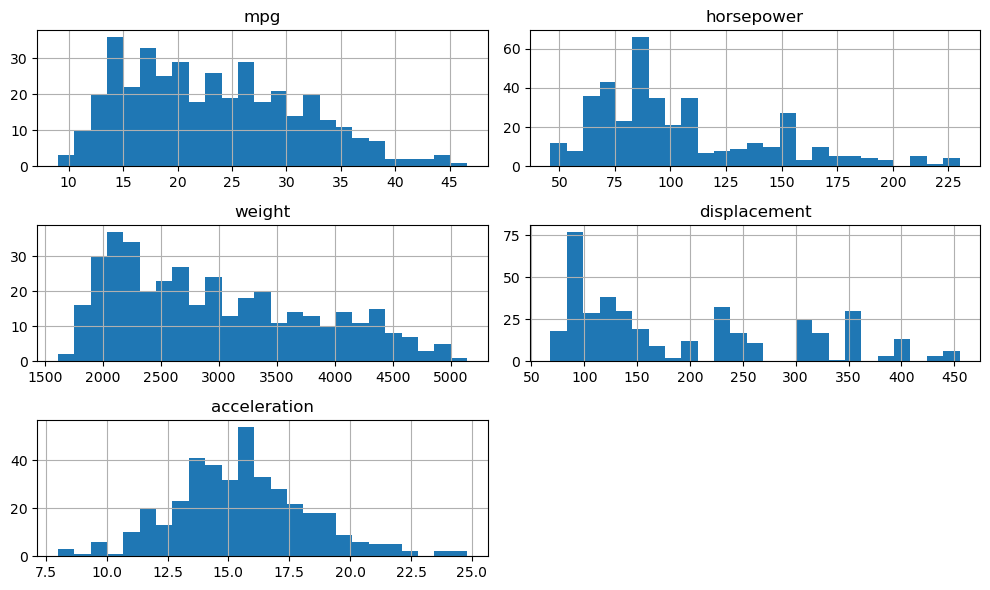

In [6]:
num_cols = ["mpg","horsepower","weight","displacement","acceleration"]
df[num_cols].hist(figsize=(10,6), bins=25)
plt.tight_layout()
plt.show()


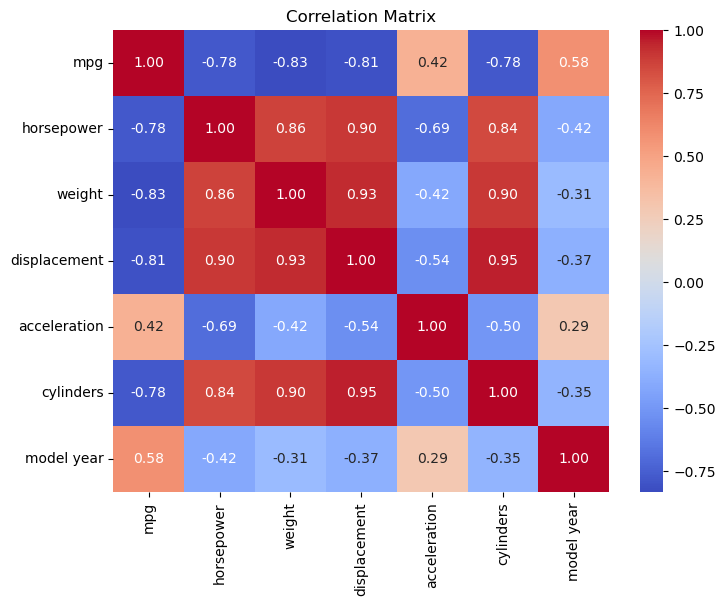

In [7]:
corr = df[num_cols + ["cylinders","model year"]].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


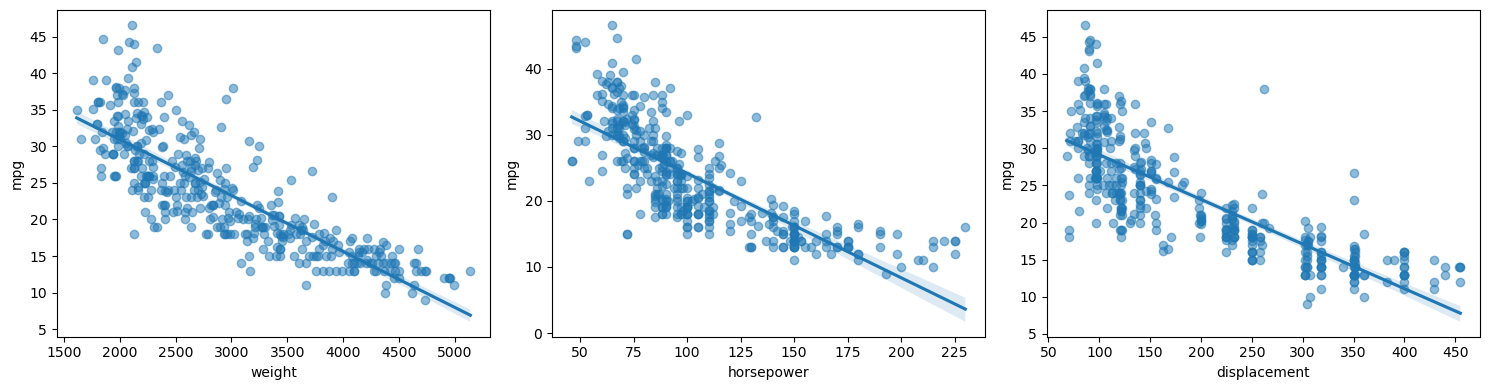

In [8]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.regplot(data=df, x="weight", y="mpg", ax=axes[0], scatter_kws={"alpha":0.5})
sns.regplot(data=df, x="horsepower", y="mpg", ax=axes[1], scatter_kws={"alpha":0.5})
sns.regplot(data=df, x="displacement", y="mpg", ax=axes[2], scatter_kws={"alpha":0.5})
plt.tight_layout()
plt.show()


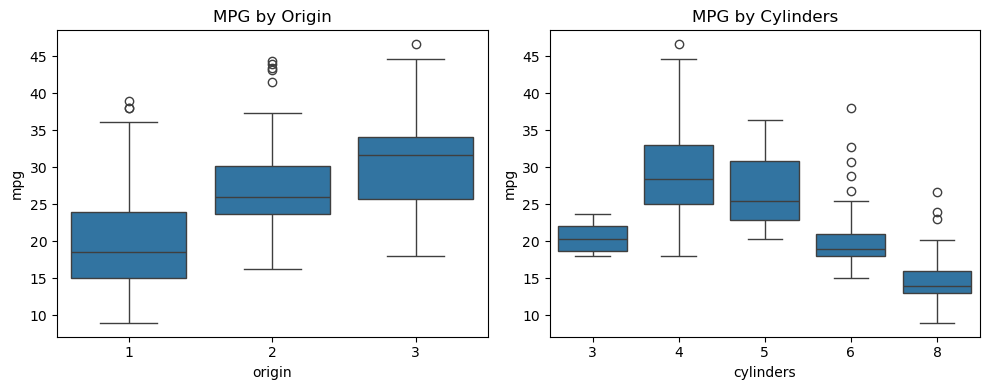

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(data=df, x="origin", y="mpg")
plt.title("MPG by Origin")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="cylinders", y="mpg")
plt.title("MPG by Cylinders")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import pandas as pd

X = df[["cylinders","displacement","horsepower","weight","acceleration","model year","origin"]]
y = df["mpg"]

cat_cols = ["origin"]
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)

imp = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# 關鍵修正：用原始欄位名（與 permutation 輸出長度一致）
imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": imp.importances_mean
}).sort_values("importance", ascending=False)

print(imp_df)




        feature  importance
5    model year    0.292867
1  displacement    0.137131
3        weight    0.109059
2    horsepower    0.077417
4  acceleration    0.018065
0     cylinders    0.008886
6        origin    0.005122


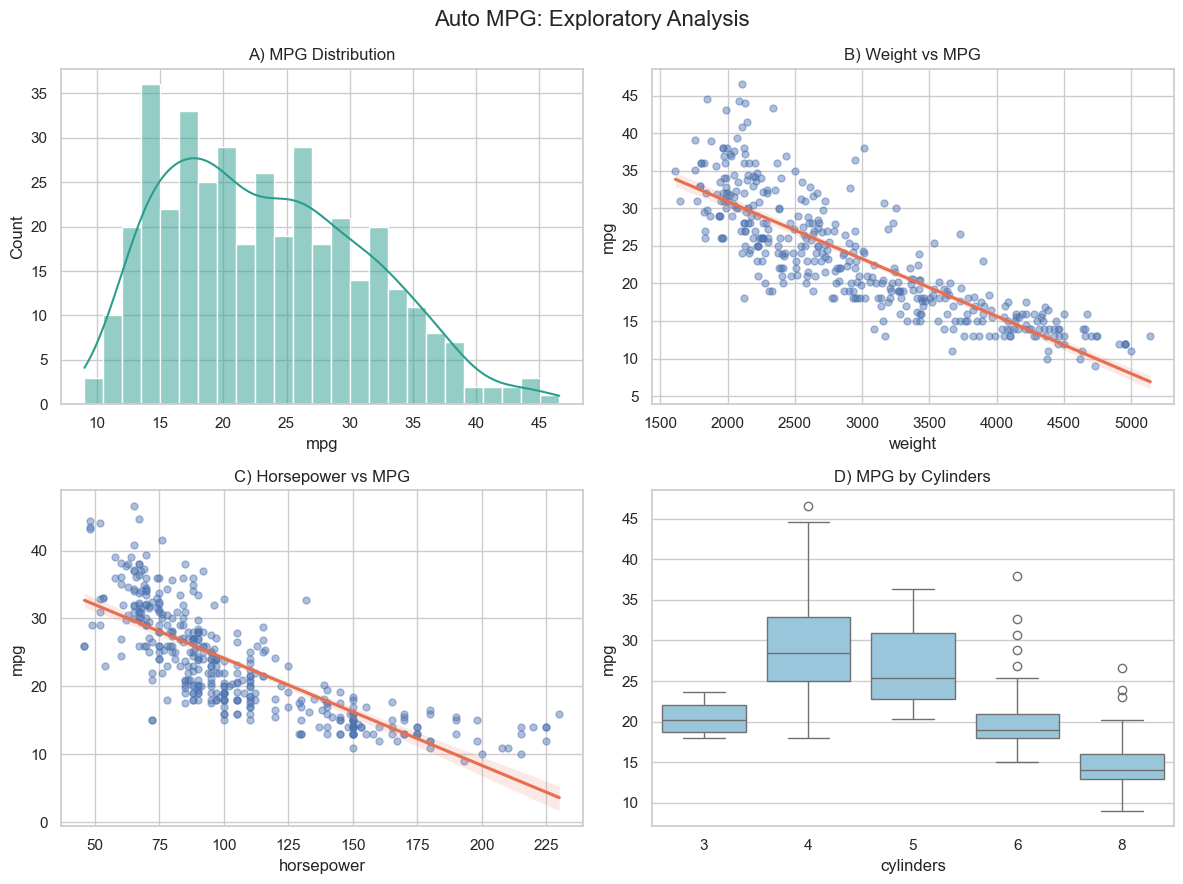


Top features:
         feature  importance
5    model year    0.301566
1  displacement    0.144346
3        weight    0.115172
2    horsepower    0.074907
4  acceleration    0.018695
6        origin    0.006688
0     cylinders    0.005767


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# ---------- 1) load + clean ----------
df = pd.read_csv("auto-mpg.csv")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["mpg","cylinders","displacement","horsepower","weight","acceleration","model year","origin"])

# ---------- 2) one-page figure ----------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Auto MPG: Exploratory Analysis", fontsize=16, y=0.98)

# A. mpg distribution
sns.histplot(df["mpg"], bins=25, kde=True, ax=axes[0,0], color="#2a9d8f")
axes[0,0].set_title("A) MPG Distribution")

# B. weight vs mpg
sns.regplot(data=df, x="weight", y="mpg", scatter_kws={"alpha":0.45, "s":25},
            line_kws={"color":"#e76f51"}, ax=axes[0,1])
axes[0,1].set_title("B) Weight vs MPG")

# C. horsepower vs mpg
sns.regplot(data=df, x="horsepower", y="mpg", scatter_kws={"alpha":0.45, "s":25},
            line_kws={"color":"#e76f51"}, ax=axes[1,0])
axes[1,0].set_title("C) Horsepower vs MPG")

# D. mpg by cylinders
sns.boxplot(data=df, x="cylinders", y="mpg", ax=axes[1,1], color="#8ecae6")
axes[1,1].set_title("D) MPG by Cylinders")

plt.tight_layout()
plt.savefig("auto_mpg_onepage.png", dpi=200)
plt.show()

# ---------- 3) feature importance ----------
X = df[["cylinders","displacement","horsepower","weight","acceleration","model year","origin"]]
y = df["mpg"]

cat_cols = ["origin"]
num_cols = [c for c in X.columns if c not in cat_cols]

pre = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=400, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# 用原始欄位名稱，不要用 one-hot 後名稱
imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print("\nTop features:\n", imp_df)

